# Parte 1: Análisis Exploratorio de Datos (EDA)
---

## 0. Carga de librerías y datos


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

SEED = 42
np.random.seed(SEED)

DATA_PATH = '../documentos/dataset_prueba.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (299997, 56)


,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_t2c_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_t2o_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number
0,8/31/2014,213.803,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.160,4.130,1.150,5.440,0.000,0.000,0.000,0.000,0.000,5.440,0.000,0.000,0.000,2,252,252,8/8/2014,252,8/8/2014,1.000,252.000,0.000,1.000,252.000,5.750,109.610,212.170,212.170,0.000,0,0,1,0,1.000,0,7000842753
1,8/31/2014,268.321,7.680,304.760,0.000,0.000,7.680,291.860,0.000,0.000,299.540,0.000,0.130,0.000,0.000,0.130,0.000,12.760,0.000,312.440,29.230,375.580,3.610,408.430,2.350,12.490,0.000,0.000,14.840,423.280,0.000,0.000,0.000,11,283,65,8/28/2014,30,8/10/2014,2.000,25.000,2.000,0.000,50.000,365.470,0.000,0.000,7.600,0.000,0,2,0,0,1.000,0,7001865778
2,8/31/2014,210.226,37.260,208.360,0.000,0.000,13.580,38.460,15.610,45.760,67.660,22.580,75.530,22.830,0.000,120.940,0.000,96.840,0.000,285.460,67.460,38.890,49.630,155.990,28.690,167.090,43.230,0.000,239.030,395.030,0.000,0.000,0.000,2,116,86,8/14/2014,86,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,NaN,NaN,NaN,0,0,0,0,NaN,0,7001625959


## 0.1 Inspección inicial del dataset

In [12]:
print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print()
print('=== Primeras columnas ===')
print(df.columns.tolist())

=== Tipos de datos ===
float64    43
int64      10
str         3
Name: count, dtype: int64

=== Primeras columnas ===
['last_date_of_month', 'arpu', 'onnet_mou', 'offnet_mou', 'roam_ic_mou', 'roam_og_mou', 'loc_og_t2t_mou', 'loc_og_t2m_mou', 'loc_og_t2f_mou', 'loc_og_t2c_mou', 'loc_og_mou', 'std_og_t2t_mou', 'std_og_t2m_mou', 'std_og_t2f_mou', 'std_og_t2c_mou', 'std_og_mou', 'isd_og_mou', 'spl_og_mou', 'og_others', 'total_og_mou', 'loc_ic_t2t_mou', 'loc_ic_t2m_mou', 'loc_ic_t2f_mou', 'loc_ic_mou', 'std_ic_t2t_mou', 'std_ic_t2m_mou', 'std_ic_t2f_mou', 'std_ic_t2o_mou', 'std_ic_mou', 'total_ic_mou', 'spl_ic_mou', 'isd_ic_mou', 'ic_others', 'total_rech_num', 'total_rech_amt', 'max_rech_amt', 'date_of_last_rech', 'last_day_rch_amt', 'date_of_last_rech_data', 'total_rech_data', 'max_rech_data', 'count_rech_2g', 'count_rech_3g', 'av_rech_amt_data', 'vol_2g_mb', 'vol_3g_mb', 'arpu_3g', 'arpu_2g', 'night_pck_user', 'monthly_2g', 'sachet_2g', 'monthly_3g', 'sachet_3g', 'fb_user', 'churn', 'mobi

In [13]:
print('=== Valores nulos por columna (top 20) ===')
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].head(20))
print(f'\nTotal de columnas con nulos: {(null_pct > 0).sum()}')

=== Valores nulos por columna (top 20) ===
total_rech_data          74.312
av_rech_amt_data         74.312
night_pck_user           74.312
max_rech_data            74.312
arpu_3g                  74.312
arpu_2g                  74.312
count_rech_3g            74.312
count_rech_2g            74.312
date_of_last_rech_data   74.312
fb_user                  74.312
ic_others                 4.391
isd_ic_mou                4.391
spl_ic_mou                4.391
std_ic_t2o_mou            4.391
std_ic_t2f_mou            4.391
std_ic_t2m_mou            4.391
std_ic_t2t_mou            4.391
loc_ic_mou                4.391
loc_ic_t2f_mou            4.391
loc_ic_t2m_mou            4.391
dtype: float64

Total de columnas con nulos: 41


In [14]:
df.isna().sum().nlargest(10)

date_of_last_rech_data    222934
total_rech_data           222934
max_rech_data             222934
count_rech_2g             222934
count_rech_3g             222934
av_rech_amt_data          222934
arpu_3g                   222934
arpu_2g                   222934
night_pck_user            222934
fb_user                   222934
dtype: int64

In [15]:
print('=== Distribución de la variable objetivo: churn ===')
print(df['churn'].value_counts())
print(f'\nTasa de churn global: {df["churn"].mean()*100:.2f}%')

=== Distribución de la variable objetivo: churn ===
churn
0    293918
1      6079
Name: count, dtype: int64

Tasa de churn global: 2.03%


## 0.2 Separación Train / Test por fecha

- **Train:** meses Junio (06/30/2014) y Julio (07/31/2014)
- **Test:** mes Agosto (08/31/2014)

In [18]:
df['last_date_of_month'] = pd.to_datetime(df['last_date_of_month'])

train_dates = ['2014-06-30', '2014-07-31']
test_date   = '2014-08-31'

df_train = df[df['last_date_of_month'].isin(pd.to_datetime(train_dates))].copy()
df_test  = df[df['last_date_of_month'] == pd.to_datetime(test_date)].copy()

print(f'Train: {len(df_train):,} registros')
print(f'Test:  {len(df_test):,} registros')
print()
print(f'Churn en train: {df_train["churn"].mean()*100:.2f}%')
print(f'Churn en test:  {df_test["churn"].mean()*100:.2f}%')

Train: 199,397 registros
Test:  98,899 registros

Churn en train: 1.28%
Churn en test:  1.90%


---
## 1. Segmentación de clientes por Revenue (ARPU)

### Criterio elegido: Percentiles con lógica de negocio (quintiles ajustados)

**Justificación del criterio:**
Se usa la distribución percentil del ARPU en los datos de entrenamiento (no en test, para no contaminar) con los siguientes segmentos:

| Segmento | Criterio | Descripción |
|----------|---------|-------------|
| Bajo | ARPU ≤ P25 | Clientes de bajo valor, posiblemente prepago básico |
| Medio | P25 < ARPU ≤ P75 | Clientes medios, el grueso de la base |
| Alto | P75 < ARPU ≤ P90 | Clientes de alto valor |
| Premium | ARPU > P90 | Clientes premium, mayor contribución al revenue |

**Por qué no K-means o deciles simples:**
La segmentación percentil es interpretable para el negocio, estable ante nuevos datos, y no requiere reentrenamiento. K-means podría crear segmentos no accionables. Los deciles son demasiado granulares para una segmentación comercial.

In [20]:
p25 = df_train['arpu'].quantile(0.25)
p75 = df_train['arpu'].quantile(0.75)
p90 = df_train['arpu'].quantile(0.90)

print(f'Percentiles de ARPU (train): P25={p25:.1f} | P75={p75:.1f} | P90={p90:.1f}')
print(f'ARPU mínimo: {df_train["arpu"].min():.1f} | máximo: {df_train["arpu"].max():.1f}')

def segmentar_arpu(arpu, p25, p75, p90):
    if arpu <= p25:
        return 'Bajo'
    elif arpu <= p75:
        return 'Medio'
    elif arpu <= p90:
        return 'Alto'
    else:
        return 'Premium'

for d in [df_train, df_test, df]:
    d['arpu_segment'] = d['arpu'].apply(segmentar_arpu, args=(p25, p75, p90))

seg_order = ['Bajo', 'Medio', 'Alto', 'Premium']

seg_stats = df_train.groupby('arpu_segment').agg(
    n_clientes=('mobile_number', 'count'),
    arpu_min=('arpu', 'min'),
    arpu_mean=('arpu', 'mean'),
    arpu_max=('arpu', 'max'),
    churn_rate=('churn', 'mean')
).loc[seg_order]
seg_stats['pct_clientes'] = seg_stats['n_clientes'] / seg_stats['n_clientes'].sum() * 100
seg_stats['churn_rate'] = seg_stats['churn_rate'] * 100
print(seg_stats)

Percentiles de ARPU (train): P25=90.8 | P75=369.1 | P90=619.6
ARPU mínimo: -2258.7 | máximo: 35145.8
              n_clientes  arpu_min  arpu_mean  arpu_max  churn_rate  \
arpu_segment                                                          
Bajo               49850 -2258.709     40.682    90.824       2.770   
Medio              99698    90.825    205.995   369.082       0.838   
Alto               29909   369.084    473.124   619.617       0.685   
Premium            19940   619.623    974.719 35145.834       0.652   

              pct_clientes  
arpu_segment                
Bajo                25.000  
Medio               50.000  
Alto                15.000  
Premium             10.000  


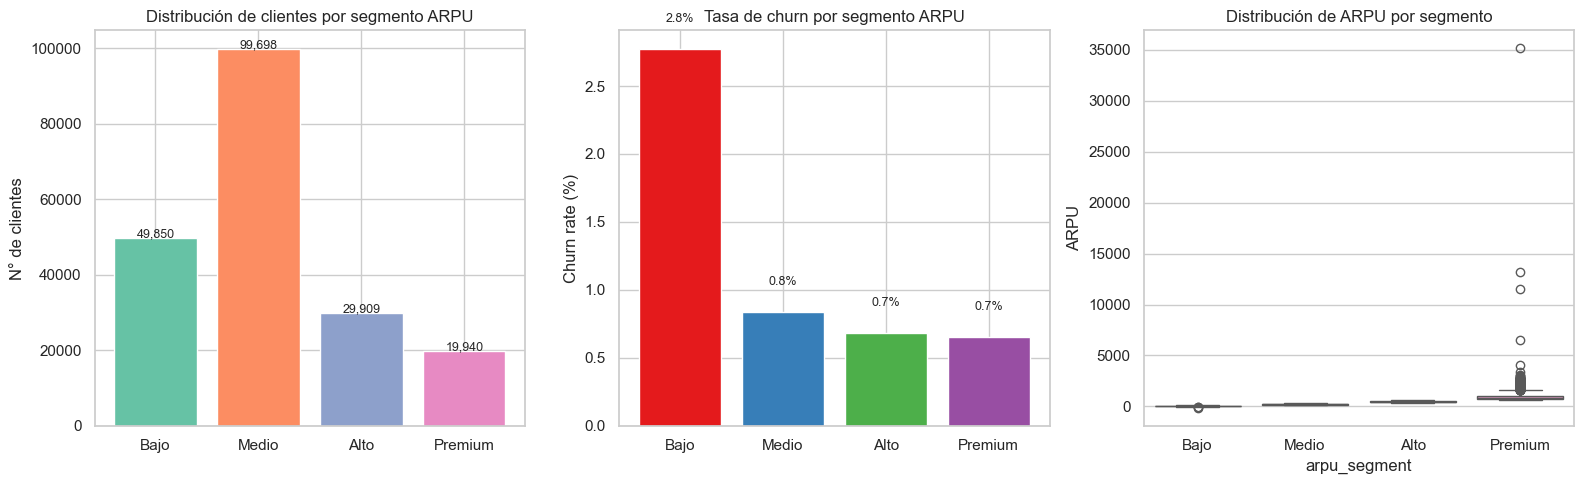

Figura guardada.


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de clientes
counts = df_train['arpu_segment'].value_counts().loc[seg_order]
axes[0].bar(seg_order, counts.values, color=sns.color_palette('Set2', 4))
axes[0].set_title('Distribución de clientes por segmento ARPU')
axes[0].set_ylabel('N° de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Churn rate por segmento
churn_by_seg = df_train.groupby('arpu_segment')['churn'].mean().loc[seg_order] * 100
bars = axes[1].bar(seg_order, churn_by_seg.values, color=sns.color_palette('Set1', 4))
axes[1].set_title('Tasa de churn por segmento ARPU')
axes[1].set_ylabel('Churn rate (%)')
for bar, v in zip(bars, churn_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Boxplot ARPU por segmento
df_train_sample = df_train.sample(min(20000, len(df_train)), random_state=SEED)
sns.boxplot(data=df_train_sample, x='arpu_segment', y='arpu', order=seg_order, ax=axes[2], palette='Set2')
axes[2].set_title('Distribución de ARPU por segmento')
axes[2].set_ylabel('ARPU')

plt.tight_layout()
plt.show()
print('Figura guardada.')

## 2. Generación de variables (Feature Engineering)


In [22]:
def crear_features(data):
    d = data.copy()

    # ---------------------------------------------------------------
    # 1. Ratio de uso de datos 3G vs 2G
    # Justificación: clientes que migran de 2G a 3G son más valiosos y
    # menos propensos a irse. Un ratio bajo indica bajo engagement digital.
    # ---------------------------------------------------------------
    total_vol = d['vol_2g_mb'] + d['vol_3g_mb']
    d['ratio_3g_vs_total'] = np.where(total_vol > 0, d['vol_3g_mb'] / total_vol, 0)

    # ---------------------------------------------------------------
    # 2. Actividad total de voz (outgoing + incoming)
    # Justificación: clientes con bajo uso de voz tienen menor
    # engagement con la red, lo que puede preceder al churn.
    # ---------------------------------------------------------------
    d['total_voz_mou'] = d['total_og_mou'].fillna(0) + d['total_ic_mou'].fillna(0)

    # ---------------------------------------------------------------
    # 3. Proporción de llamadas en roaming vs total
    # Justificación: clientes que roaman frecuentemente pueden cambiar
    # de operador si encuentran mejores tarifas internacionales.
    # ---------------------------------------------------------------
    roam_total = d['roam_ic_mou'].fillna(0) + d['roam_og_mou'].fillna(0)
    d['ratio_roam'] = np.where(d['total_voz_mou'] > 0, roam_total / d['total_voz_mou'], 0)

    # ---------------------------------------------------------------
    # 4. ¿El cliente recargó datos en el mes?
    # Justificación: clientes sin recargas de datos en un mes son
    # señal de desengagement (posible churn inminente).
    # ---------------------------------------------------------------
    d['hizo_recarga_datos'] = (d['total_rech_data'].fillna(0) > 0).astype(int)

    # ---------------------------------------------------------------
    # 5. ARPU relativo: diferencia entre ARPU del cliente y ARPU promedio
    # Justificación: captura si el cliente está por encima o debajo del
    # promedio, útil para identificar clientes en riesgo de downgrade.
    # ---------------------------------------------------------------
    arpu_mean = d['arpu'].mean()
    d['arpu_vs_media'] = d['arpu'] - arpu_mean

    # ---------------------------------------------------------------
    # 6. Monto promedio por recarga
    # Justificación: capturas si el cliente recarga con montos bajos y
    # frecuentes (prepago puro) vs. montos altos pero esporádicos.
    # ---------------------------------------------------------------
    d['avg_rech_amt'] = np.where(
        d['total_rech_num'] > 0,
        d['total_rech_amt'] / d['total_rech_num'],
        0
    )

    # ---------------------------------------------------------------
    # 7. Usuario de datos: binario si usa 2G o 3G
    # Justificación: segmenta usuarios de voz pura vs usuarios digitales.
    # Los usuarios digitales tienen mayor LTV y menor churn en general.
    # ---------------------------------------------------------------
    d['es_usuario_datos'] = ((d['vol_2g_mb'].fillna(0) + d['vol_3g_mb'].fillna(0)) > 0).astype(int)

    # ---------------------------------------------------------------
    # 8. Balance llamadas emitidas vs recibidas
    # Justificación: clientes que solo reciben pero no emiten pueden
    # estar usando otro operador como principal.
    # ---------------------------------------------------------------
    d['balance_og_ic'] = d['total_og_mou'].fillna(0) - d['total_ic_mou'].fillna(0)

    return d

df_train = crear_features(df_train)
df_test  = crear_features(df_test)

new_features = ['ratio_3g_vs_total', 'total_voz_mou', 'ratio_roam',
                'hizo_recarga_datos', 'arpu_vs_media', 'avg_rech_amt',
                'es_usuario_datos', 'balance_og_ic']

print('Features creadas:')
print(df_train[new_features].describe().T[['mean', 'std', 'min', 'max']])

Features creadas:
                      mean     std       min       max
ratio_3g_vs_total    0.125   0.313     0.000     1.000
total_voz_mou      510.709 611.222     0.000 12311.260
ratio_roam           0.244   9.889     0.000  1710.692
hizo_recarga_datos   0.254   0.436     0.000     1.000
arpu_vs_media        0.000 333.485 -2540.317 34864.226
avg_rech_amt        46.985  56.448     0.000  4010.000
es_usuario_datos     0.237   0.425     0.000     1.000
balance_og_ic      106.511 496.585 -8991.150 11254.330


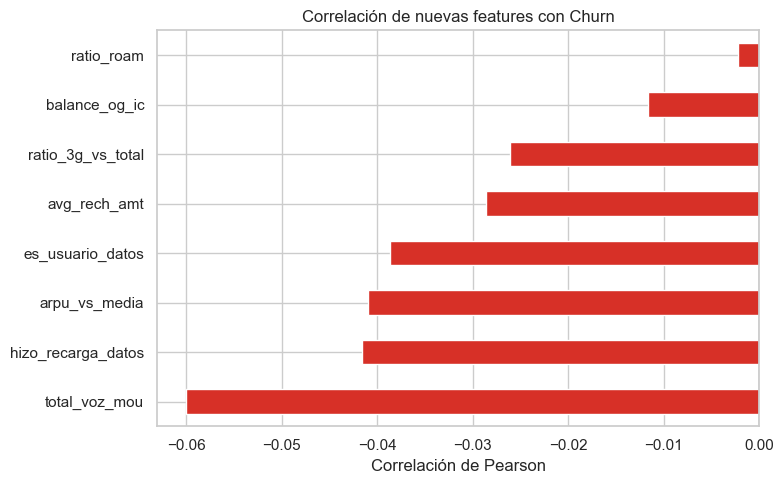

In [23]:
# Correlación de nuevas features con churn
correlaciones = df_train[new_features + ['churn']].corr()['churn'].drop('churn').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d73027' if v < 0 else '#1a9850' for v in correlaciones.values]
correlaciones.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de nuevas features con Churn')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 3. Análisis de Churn

### 3.1 Tasa de churn por mes

In [25]:
churn_por_mes = df.groupby('last_date_of_month')['churn'].agg(['mean', 'sum', 'count'])
churn_por_mes.columns = ['churn_rate', 'n_churners', 'n_total']
churn_por_mes['churn_rate_pct'] = churn_por_mes['churn_rate'] * 100
print(churn_por_mes)

                    churn_rate  n_churners  n_total  churn_rate_pct
last_date_of_month                                                 
2014-06-30               0.010        1038    99999           1.038
2014-07-31               0.015        1513    99398           1.522
2014-08-31               0.019        1882    98899           1.903


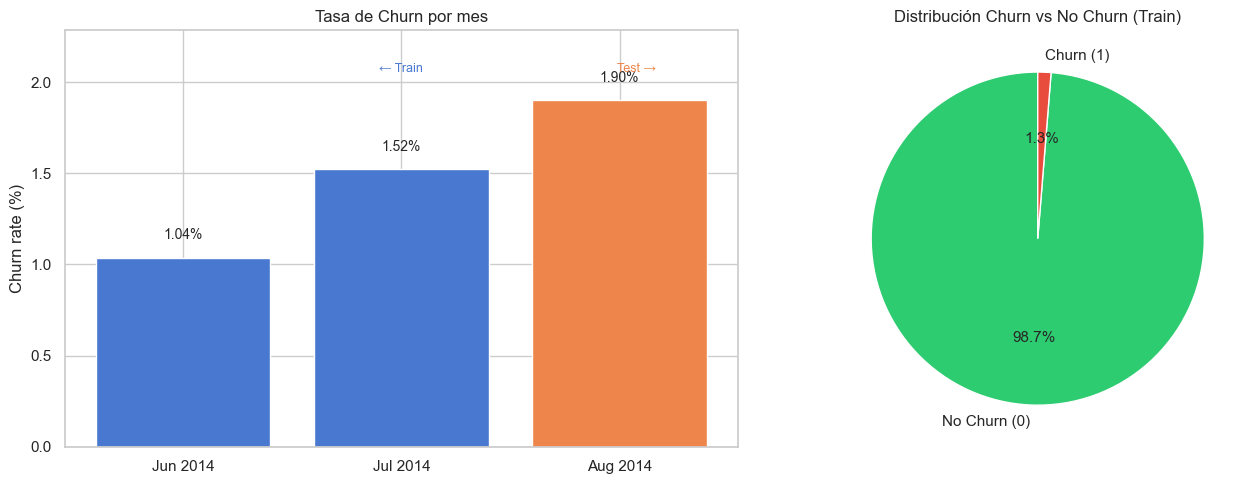

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate por mes
meses = churn_por_mes.index.strftime('%b %Y')
axes[0].bar(meses, churn_por_mes['churn_rate_pct'], color=['#4878d0', '#4878d0', '#ee854a'])
axes[0].set_title('Tasa de Churn por mes')
axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(churn_por_mes['churn_rate_pct']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10)
axes[0].set_ylim(0, churn_por_mes['churn_rate_pct'].max() * 1.2)
axes[0].annotate('← Train', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', color='#4878d0', fontsize=9)
axes[0].annotate('Test →', xy=(0.85, 0.9), xycoords='axes fraction', ha='center', color='#ee854a', fontsize=9)

# Distribución churn vs no churn en train
churn_counts = df_train['churn'].value_counts()
labels = ['No Churn (0)', 'Churn (1)']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribución Churn vs No Churn (Train)')

plt.tight_layout()
plt.show()

### 3.2 Variables más relacionadas con el churn

In [27]:
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()
exclude = ['churn', 'mobile_number']
num_cols = [c for c in num_cols if c not in exclude]

corr_churn = df_train[num_cols + ['churn']].corr()['churn'].drop('churn').abs().sort_values(ascending=False)

print('Top 20 variables más correlacionadas con churn (valor absoluto):')
print(corr_churn.head(20))

Top 20 variables más correlacionadas con churn (valor absoluto):
total_voz_mou        0.060
total_rech_num       0.057
total_ic_mou         0.052
total_rech_amt       0.050
total_og_mou         0.045
max_rech_amt         0.043
hizo_recarga_datos   0.042
arpu                 0.041
arpu_vs_media        0.041
es_usuario_datos     0.039
last_day_rch_amt     0.032
avg_rech_amt         0.029
ratio_3g_vs_total    0.026
monthly_2g           0.024
loc_ic_mou           0.022
loc_ic_t2m_mou       0.021
vol_2g_mb            0.021
sachet_2g            0.020
loc_og_mou           0.020
vol_3g_mb            0.019
Name: churn, dtype: float64


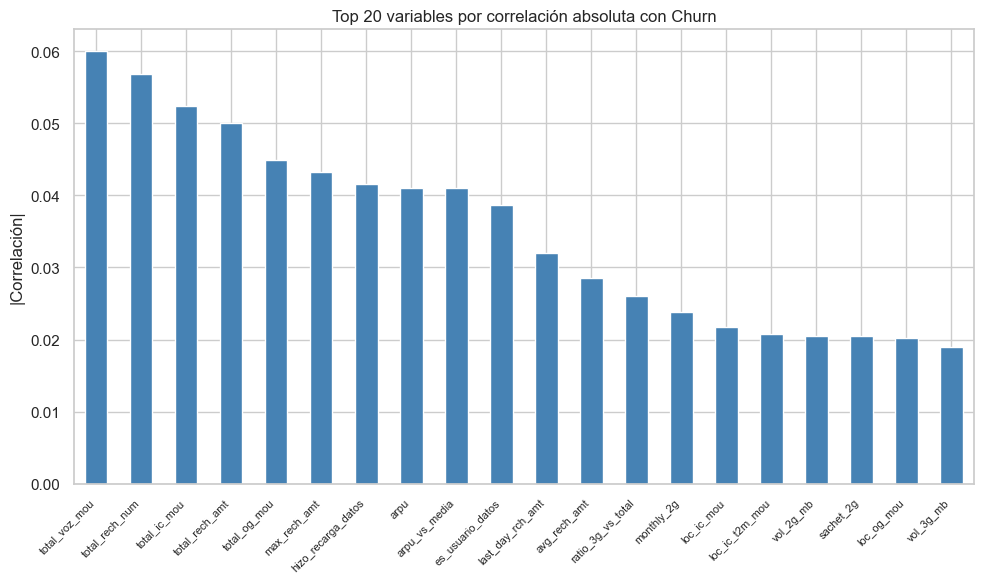

In [28]:
top_vars = corr_churn.head(12).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
corr_churn.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 20 variables por correlación absoluta con Churn')
ax.set_ylabel('|Correlación|')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Comparación: Clientes con churn vs sin churn

In [29]:
key_vars = ['arpu', 'total_og_mou', 'total_ic_mou', 'total_rech_amt',
            'vol_2g_mb', 'vol_3g_mb', 'total_voz_mou', 'avg_rech_amt']

comparacion = df_train.groupby('churn')[key_vars].median()
comparacion.index = ['No Churn', 'Churn']
print('Mediana de variables clave por grupo:')
print(comparacion.T.to_string())

Mediana de variables clave por grupo:
                No Churn  Churn
arpu             197.099 75.120
total_og_mou     146.230  0.000
total_ic_mou     117.780  0.000
total_rech_amt   229.000 30.000
vol_2g_mb          0.000  0.000
vol_3g_mb          0.000  0.000
total_voz_mou    325.850  0.000
avg_rech_amt      34.714 10.000


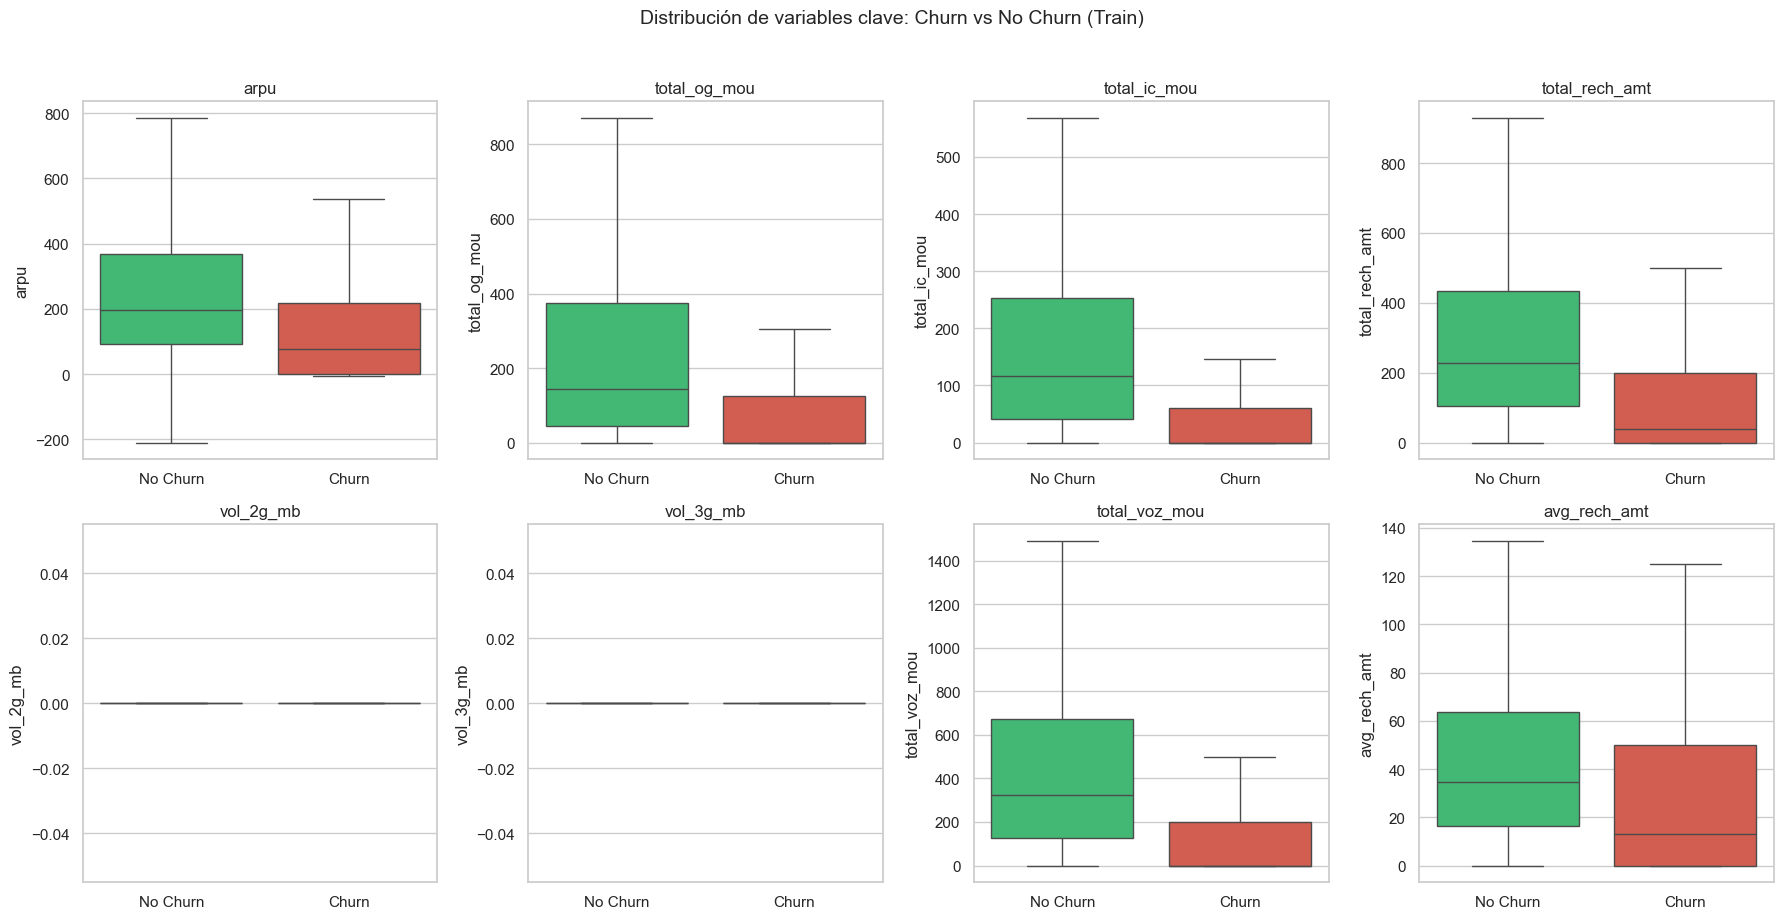

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

sample = df_train.sample(min(30000, len(df_train)), random_state=SEED).copy()
sample['churn_label'] = sample['churn'].map({0: 'No Churn', 1: 'Churn'})

for i, var in enumerate(key_vars):
    sns.boxplot(
        data=sample, x='churn_label', y=var, ax=axes[i],
        order=['No Churn', 'Churn'],
        palette={'No Churn': '#2ecc71', 'Churn': '#e74c3c'},
        showfliers=False
    )
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables clave: Churn vs No Churn (Train)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Análisis de churn por segmento ARPU


In [32]:
churn_seg = df_train.groupby('arpu_segment')['churn'].agg(['mean', 'sum', 'count']).loc[seg_order]
churn_seg.columns = ['churn_rate', 'churners', 'total']
churn_seg['churn_rate_pct'] = churn_seg['churn_rate'] * 100
print(churn_seg)

              churn_rate  churners  total  churn_rate_pct
arpu_segment                                             
Bajo               0.028      1381  49850           2.770
Medio              0.008       835  99698           0.838
Alto               0.007       205  29909           0.685
Premium            0.007       130  19940           0.652


---
## 4. Limpieza de Datos




In [33]:
# Análisis de nulos detallado
null_info = pd.DataFrame({
    'n_nulos': df_train.isnull().sum(),
    'pct_nulos': df_train.isnull().sum() / len(df_train) * 100,
    'dtype': df_train.dtypes
}).sort_values('pct_nulos', ascending=False)

print('Columnas con valores nulos (train):')
print(null_info[null_info['n_nulos'] > 0].to_string())

Columnas con valores nulos (train):
                        n_nulos  pct_nulos    dtype
fb_user                  148673     74.561  float64
count_rech_3g            148673     74.561  float64
total_rech_data          148673     74.561  float64
max_rech_data            148673     74.561  float64
count_rech_2g            148673     74.561  float64
date_of_last_rech_data   148673     74.561      str
av_rech_amt_data         148673     74.561  float64
arpu_3g                  148673     74.561  float64
arpu_2g                  148673     74.561  float64
night_pck_user           148673     74.561  float64
loc_ic_t2t_mou             7195      3.608  float64
isd_ic_mou                 7195      3.608  float64
spl_ic_mou                 7195      3.608  float64
std_ic_mou                 7195      3.608  float64
std_ic_t2o_mou             7195      3.608  float64
std_ic_t2f_mou             7195      3.608  float64
std_ic_t2t_mou             7195      3.608  float64
loc_ic_mou                 7

In [34]:
# Identificar columnas a eliminar por alta tasa de nulos
HIGH_NULL_THRESHOLD = 0.70  # 70%
cols_high_null = null_info[null_info['pct_nulos'] > HIGH_NULL_THRESHOLD * 100].index.tolist()
print(f'Columnas con >{HIGH_NULL_THRESHOLD*100:.0f}% nulos: {cols_high_null}')

# Columnas identificadoras que no aportan al modelo
cols_id = ['mobile_number', 'last_date_of_month', 'date_of_last_rech', 'date_of_last_rech_data']

# Columnas de baja varianza o redundantes (a verificar)
print('\nVarianza de columnas numéricas (sample de las más bajas):')
var_cols = df_train.select_dtypes(include=np.number).var().sort_values()
print(var_cols.head(10))

Columnas con >70% nulos: ['fb_user', 'count_rech_3g', 'total_rech_data', 'max_rech_data', 'count_rech_2g', 'date_of_last_rech_data', 'av_rech_amt_data', 'arpu_3g', 'arpu_2g', 'night_pck_user']

Varianza de columnas numéricas (sample de las más bajas):
std_ic_t2o_mou      0.000
std_og_t2c_mou      0.000
churn               0.013
night_pck_user      0.023
spl_ic_mou          0.025
fb_user             0.081
monthly_2g          0.090
ratio_3g_vs_total   0.098
monthly_3g          0.141
es_usuario_datos    0.181
dtype: float64


In [44]:
zero_var_cols = var_cols[var_cols == 0].index.tolist()
print(f'Columnas con varianza cero: {zero_var_cols}')

Columnas con varianza cero: ['std_ic_t2o_mou', 'std_og_t2c_mou']


In [38]:
"""
ESTRATEGIA DE LIMPIEZA ADOPTADA:

1. COLUMNAS ELIMINADAS:
   - Columnas identificadoras: mobile_number, last_date_of_month,
     date_of_last_rech, date_of_last_rech_data
     → No aportan información predictiva y pueden causar leakage.
   - Columnas con >70% de nulos: se eliminarán si existen
     → Con tan pocos datos, imputar introduce más ruido que señal.
   - Columnas con varianza cero: no tienen poder discriminativo.

2. TRATAMIENTO DE NULOS RESTANTES:
   - Variables de uso/minutos/datos: se imputan con 0
     → Nulo aquí significa que el cliente no usó ese servicio ese mes.
     → Esta es una suposición razonable en contexto TELCO.
   - Variables de recharge (total_rech_data, max_rech_data, etc.):
     se imputan con 0 (no hubo recarga de datos).
   - Columnas de texto/fecha con nulos: se tratan según caso.

3. DESCONFIANZA:
   - arpu < 0: debería ser imposible. Se revisa si existen.
   - Clientes con 0 en todas las variables de uso por 2+ meses
     seguidos: pueden ser cuentas inactivas ya churnadas.
   - Fechas inconsistentes en recargas.

4. RIESGOS DEL ENFOQUE:
   - Imputar nulos de datos con 0 puede confundir 'no uso' con
     'dato faltante por error de captura'.
   - Si hay sesgo en los datos faltantes (MNAR), la imputación
     puede introducir bias sistemático.
"""
print()

In [39]:
# Verificar valores negativos en ARPU
print(f'Registros con ARPU < 0 (train): {(df_train["arpu"] < 0).sum()}')
print(f'Registros con ARPU = 0 (train): {(df_train["arpu"] == 0).sum()}')

# Verificar consistencia de fechas
print(f'\nFechas únicas en train: {sorted(df_train["last_date_of_month"].unique())}')

Registros con ARPU < 0 (train): 914
Registros con ARPU = 0 (train): 6992

Fechas únicas en train: [Timestamp('2014-06-30 00:00:00'), Timestamp('2014-07-31 00:00:00')]


---
## 5. Análisis adicional: Clientes inactivos y riesgo de fuga temprana

**Motivación:** En TELCO, un indicador potente de churn es la progresiva reducción de uso antes de abandonar. Si el dataset incluye 2 meses de train, podemos explorar si hay clientes con actividad decreciente.

In [40]:
# Clientes completamente inactivos (cero uso en todas las métricas principales)
uso_cols = ['total_og_mou', 'total_ic_mou', 'vol_2g_mb', 'vol_3g_mb', 'total_rech_amt']

for col in uso_cols:
    df_train[col] = df_train[col].fillna(0)

df_train['inactivo_total'] = (
    (df_train['total_og_mou'] == 0) &
    (df_train['total_ic_mou'] == 0) &
    (df_train['total_rech_amt'] == 0)
).astype(int)

print(f'Clientes completamente inactivos en train: {df_train["inactivo_total"].sum():,}')
print(f'Churn rate en inactivos: {df_train[df_train["inactivo_total"]==1]["churn"].mean()*100:.2f}%')
print(f'Churn rate en activos:   {df_train[df_train["inactivo_total"]==0]["churn"].mean()*100:.2f}%')

Clientes completamente inactivos en train: 8,977
Churn rate en inactivos: 10.82%
Churn rate en activos:   0.83%


In [41]:
# Análisis del uso de Facebook (fb_user) vs churn
if 'fb_user' in df_train.columns:
    fb_churn = df_train.groupby('fb_user')['churn'].agg(['mean', 'count'])
    fb_churn.index = ['No FB', 'FB User']
    fb_churn['churn_pct'] = fb_churn['mean'] * 100
    print('\nChurn rate según uso de Facebook:')
    print(fb_churn)


Churn rate según uso de Facebook:
         mean  count  churn_pct
No FB   0.002   4486      0.201
FB User 0.005  46238      0.506


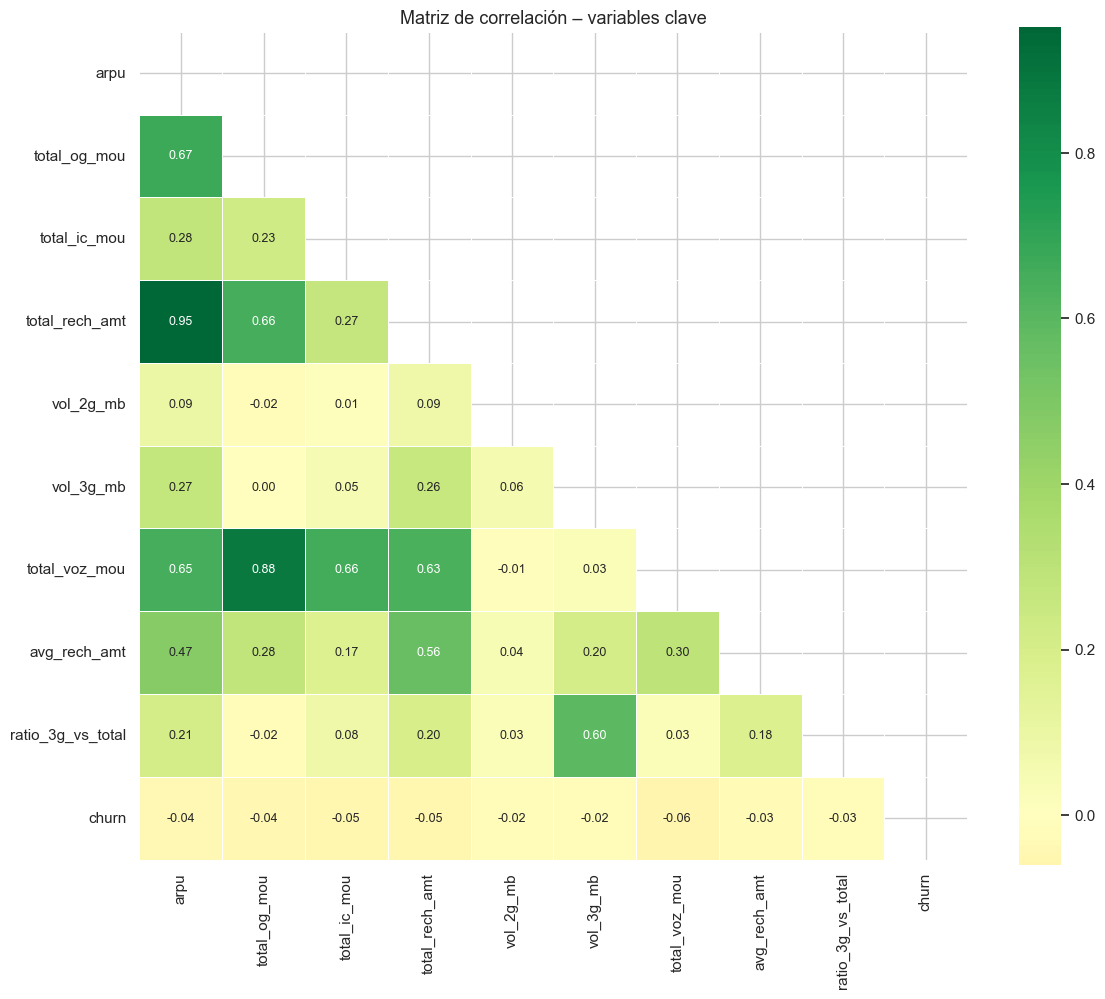

In [42]:
# Heatmap de correlaciones entre variables principales
key_corr_vars = ['arpu', 'total_og_mou', 'total_ic_mou', 'total_rech_amt',
                 'vol_2g_mb', 'vol_3g_mb', 'total_voz_mou', 'avg_rech_amt',
                 'ratio_3g_vs_total', 'churn']

corr_matrix = df_train[key_corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Matriz de correlación – variables clave', fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
print('=== RESUMEN EDA ===')
print(f'Total registros train: {len(df_train):,}')
print(f'Total registros test:  {len(df_test):,}')
print(f'Churn rate train: {df_train["churn"].mean()*100:.2f}%')
print(f'Churn rate test:  {df_test["churn"].mean()*100:.2f}%')
print(f'Dataset desbalanceado: sí → se requiere manejo especial en modelamiento')
print()
print('Segmentos ARPU:')
for seg in seg_order:
    n = (df_train['arpu_segment'] == seg).sum()
    cr = df_train[df_train['arpu_segment'] == seg]['churn'].mean()
    print(f'  {seg:8}: {n:,} clientes  |  churn rate: {cr*100:.2f}%')
print()
print('Top 5 variables más correlacionadas con churn:')
print(corr_churn.head())

=== RESUMEN EDA ===
Total registros train: 199,397
Total registros test:  98,899
Churn rate train: 1.28%
Churn rate test:  1.90%
Dataset desbalanceado: sí → se requiere manejo especial en modelamiento

Segmentos ARPU:
  Bajo    : 49,850 clientes  |  churn rate: 2.77%
  Medio   : 99,698 clientes  |  churn rate: 0.84%
  Alto    : 29,909 clientes  |  churn rate: 0.69%
  Premium : 19,940 clientes  |  churn rate: 0.65%

Top 5 variables más correlacionadas con churn:
total_voz_mou    0.060
total_rech_num   0.057
total_ic_mou     0.052
total_rech_amt   0.050
total_og_mou     0.045
Name: churn, dtype: float64
